# 🚦 DL-TOLMON — Live Traffic Monitor
**Deep Learning Based Toll Gate Traffic Prediction and Decision Support System**

Business Intelligence and Deep Learning solution for toll traffic monitoring and decision support.

Structure: **Analysis → Identify → Design → Implementation → Evaluation**

| Info | Value |
|---|---|
| Dataset | `data_tol.xlsx` (180 raw rows × 6 gates) |
| Synchronized timestamps | **880 rows** |
| Label distribution | LOW = 852 · MEDIUM = 27 · HEAVY = 1 |

## 1. Analysis
Traffic congestion in large cities creates operational inefficiency and travel-time uncertainty.
Business Intelligence is used to transform raw toll gate events into decision-oriented information.
A dense neural network classifies congestion levels into **LOW**, **MEDIUM**, and **HEAVY**.

| Study | Method | Context | Main Contribution |
|---|---|---|---|
| Urban traffic forecasting | CNN / LSTM | Highway & city | Temporal/spatial pattern capture |
| BI dashboards in transport | BI + descriptive analytics | Traffic control center | Fast interpretation & decision support |
| **This project** | **Dense Neural Network + BI Dashboard** | **Jabodetabek toll gate events** | **Tabular deep learning + live monitoring** |

In [1]:
!pip install openpyxl -q

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display, HTML
import json, base64

raw = pd.read_excel('data_tol.xlsx', header=None)
raw.columns = [f'G{i}' for i in range(1, 7)]
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (180, 6)


,G1,G2,G3,G4,G5,G6
0,1970-01-01 00:00:01,1970-01-01 00:00:00,1970-01-01 00:00:00,1970-01-01 00:00:07,1970-01-01 00:00:00,1970-01-01 00:00:07
1,1970-01-01 00:00:10,1970-01-01 00:00:10,1970-01-01 00:00:09,1970-01-01 00:00:18,1970-01-01 00:00:09,1970-01-01 00:00:30
2,1970-01-01 00:00:20,1970-01-01 00:00:21,1970-01-01 00:00:19,1970-01-01 00:00:27,1970-01-01 00:00:30,1970-01-01 00:00:41
3,1970-01-01 00:00:31,1970-01-01 00:00:31,1970-01-01 00:00:28,1970-01-01 00:01:02,1970-01-01 00:00:41,1970-01-01 00:01:00
4,1970-01-01 00:00:44,1970-01-01 00:00:41,1970-01-01 00:00:38,1970-01-01 00:01:13,1970-01-01 00:00:56,1970-01-01 00:01:16


## 2. Identify
**Problem statement:**
1. Raw timestamps are split across six toll gates — not aligned row-by-row.
2. Decision makers need synchronized timestamp rows before any BI or deep learning analysis.
3. End users need a clear recommendation: **GO**, **CAUTION**, or **NOT GO**.

**Business objective:** Clean the dataset, extract hidden patterns, predict congestion level, and display recommendation dashboard.

In [15]:
# ── Preprocessing: synchronize timestamps ─────────────────────────────────
records = []
for col in raw.columns:
    for t in raw[col].dropna():
        records.append((pd.to_datetime(t), col, 1))

events = pd.DataFrame(records, columns=['timestamp', 'gate', 'vehicle'])
pivot = events.assign(v=1).pivot_table(
    index='timestamp', columns='gate', values='v',
    aggfunc='sum', fill_value=0
).reset_index().sort_values('timestamp')

for g in [f'G{i}' for i in range(1, 7)]:
    if g not in pivot.columns: pivot[g] = 0

gate_cols = [f'G{i}' for i in range(1, 7)]
pivot['total_vehicles'] = pivot[gate_cols].sum(axis=1)

def make_label(n):
    if n <= 2:   return 'LOW'
    elif n <= 4: return 'MEDIUM'
    return 'HEAVY'

pivot['Label']   = pivot['total_vehicles'].apply(make_label)
pivot['seconds'] = (pivot['timestamp'] - pivot['timestamp'].min()).dt.total_seconds().astype(int)
pivot.to_csv('data_tol_clean_rebuilt.csv', index=False)

print('Synchronized rows:', len(pivot))
print(pivot['Label'].value_counts())
pivot.head()

Synchronized rows: 880
Label
LOW       852
MEDIUM     27
HEAVY       1
Name: count, dtype: int64


gate,timestamp,G1,G2,G3,G4,G5,G6,total_vehicles,Label,seconds
0,1970-01-01 00:00:00,0,1,1,0,1,0,3,MEDIUM,0
1,1970-01-01 00:00:01,1,0,0,0,0,0,1,LOW,1
2,1970-01-01 00:00:07,0,0,0,1,0,1,2,LOW,7
3,1970-01-01 00:00:09,0,0,1,0,1,0,2,LOW,9
4,1970-01-01 00:00:10,1,1,0,0,0,0,2,LOW,10


## 3. Design
**System architecture:**
```
Raw toll timestamps
  → Preprocessing & synchronization
  → Dense Neural Network  (MLP: 32 → 64 → 32 · ReLU · Adam)
  → predict_traffic() function
  → Live TOLMON Dashboard (rendered inline in Colab)
  → User decision: GO / CAUTION / NOT GO
```

## 4. Hidden Pattern Extraction (BI Component)

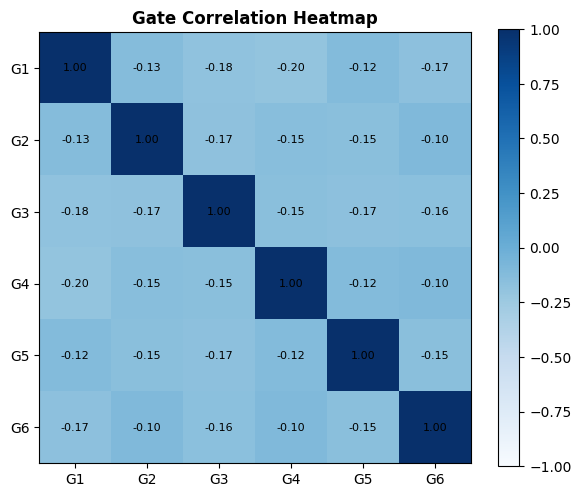

Key insight: negative inter-gate correlation → vehicles spread across gates (natural load balancing)


In [4]:
# Gate correlation heatmap
corr = pivot[gate_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='Blues', vmin=-1, vmax=1)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(gate_cols); ax.set_yticklabels(gate_cols)
plt.colorbar(im, ax=ax)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Gate Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()
print('Key insight: negative inter-gate correlation → vehicles spread across gates (natural load balancing)')

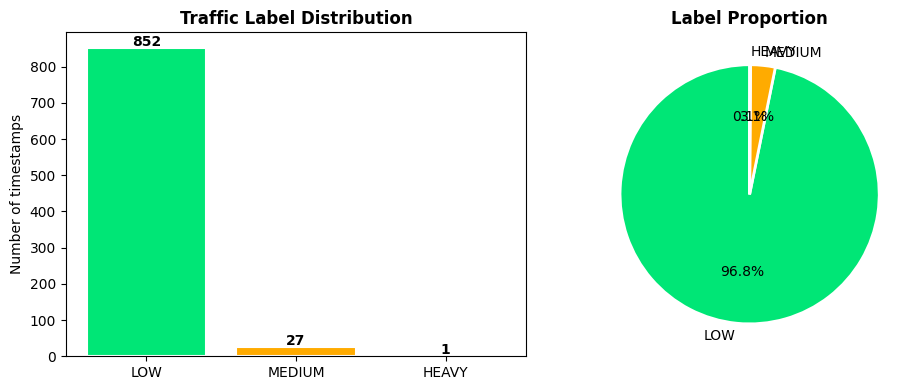

In [5]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10,4))
counts = pivot['Label'].value_counts().reindex(['LOW','MEDIUM','HEAVY'])
colors = ['#00e676','#ffab00','#ff1744']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Traffic Label Distribution', fontweight='bold')
axes[0].set_ylabel('Number of timestamps')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Label Proportion', fontweight='bold')
plt.tight_layout(); plt.show()

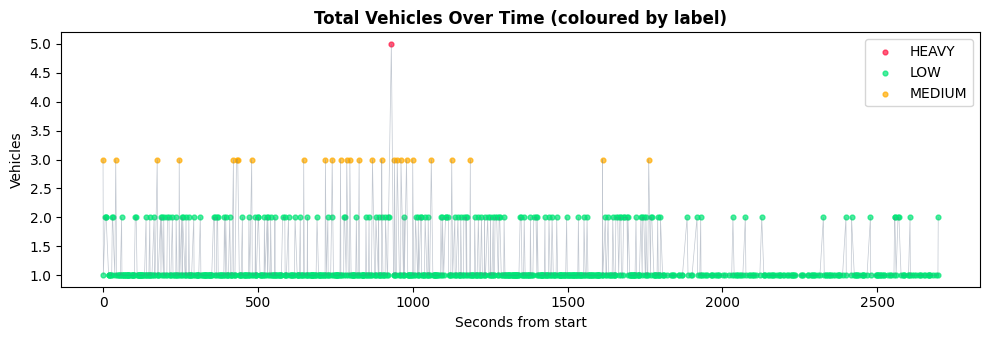

In [6]:
# Time trend
fig, ax = plt.subplots(figsize=(10,3.5))
color_map = {'LOW':'#00e676','MEDIUM':'#ffab00','HEAVY':'#ff1744'}
for label, grp in pivot.groupby('Label'):
    ax.scatter(grp['seconds'], grp['total_vehicles'],
               c=color_map[label], label=label, s=12, alpha=0.7)
ax.plot(pivot['seconds'], pivot['total_vehicles'], color='#64748b', linewidth=0.5, alpha=0.4)
ax.set_title('Total Vehicles Over Time (coloured by label)', fontweight='bold')
ax.set_xlabel('Seconds from start'); ax.set_ylabel('Vehicles')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Implementation: Dense Neural Network

In [7]:
# Train model
X = pivot[gate_cols].values
y = pivot['Label'].values
le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

model = MLPClassifier(
    hidden_layer_sizes=(32, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)
model.fit(X_train, y_train)
print('Training complete ✓')

Training complete ✓


## 6. Hyperparameter Configuration
| Parameter | Value | Reason |
|---|---|---|
| Hidden layers | (32 → 64 → 32) | Captures non-linear patterns without overfitting small dataset |
| Activation | ReLU | Avoids vanishing gradient |
| Optimizer | Adam | Adaptive LR; stable for imbalanced data |
| Learning rate | 0.001 | Stable convergence |
| Max iterations | 300 | Sufficient for 880 samples |

Accuracy: 0.9943 (99.43%)
Classes: ['HEAVY' 'LOW' 'MEDIUM']

              precision    recall  f1-score   support

       HEAVY       0.00      0.00      0.00         0
         LOW       0.99      1.00      1.00       172
      MEDIUM       1.00      0.75      0.86         4

    accuracy                           0.99       176
   macro avg       0.66      0.58      0.62       176
weighted avg       0.99      0.99      0.99       176



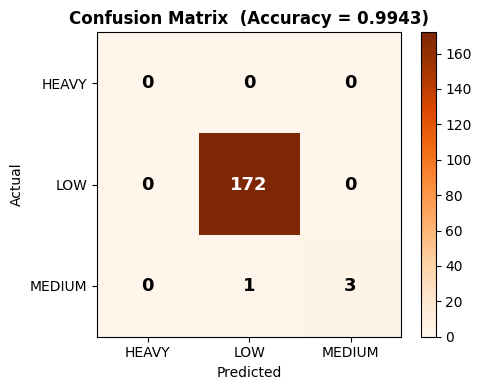

In [8]:
# Evaluation
pred = model.predict(X_test)
acc  = accuracy_score(y_test, pred)
cm   = confusion_matrix(y_test, pred, labels=[0,1,2])

print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('Classes:', le.classes_)
print()
print(classification_report(y_test, pred, labels=[0,1,2],
                             target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Oranges')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(le.classes_); ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix  (Accuracy = {acc:.4f})', fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
plt.tight_layout(); plt.show()

## 7. Real-Time Prediction Function

In [9]:
def predict_traffic(g1, g2, g3, g4, g5, g6):
    """
    Each gate is binary: 0 (no vehicle) or 1 (vehicle detected at this timestamp).
    The model was trained on binary gate features — max possible total = 6.
    """
    row   = np.array([[g1, g2, g3, g4, g5, g6]])
    enc   = model.predict(row)[0]
    label = le.inverse_transform([enc])[0]
    proba = model.predict_proba(row)[0]
    total = int(row.sum())
    rec   = 'GO' if label=='LOW' else ('CAUTION' if label=='MEDIUM' else 'NOT GO')
    return {
        'label': label,
        'total_vehicles': total,
        'recommendation': rec,
        'probabilities': dict(zip(le.classes_, proba.round(3).tolist()))
    }

# Tests
print('1 gate active (total=1):', predict_traffic(1,0,0,0,0,0))
print('3 gates active (total=3):', predict_traffic(1,1,1,0,0,0))
print('All 6 active  (total=6):', predict_traffic(1,1,1,1,1,1))

1 gate active (total=1): {'label': 'LOW', 'total_vehicles': 1, 'recommendation': 'GO', 'probabilities': {'HEAVY': 0.0, 'LOW': 1.0, 'MEDIUM': 0.0}}
3 gates active (total=3): {'label': 'MEDIUM', 'total_vehicles': 3, 'recommendation': 'CAUTION', 'probabilities': {'HEAVY': 0.006, 'LOW': 0.011, 'MEDIUM': 0.983}}
All 6 active  (total=6): {'label': 'MEDIUM', 'total_vehicles': 6, 'recommendation': 'CAUTION', 'probabilities': {'HEAVY': 0.02, 'LOW': 0.0, 'MEDIUM': 0.98}}


## 8. 📊 Live TOLMON Dashboard
Run the two cells below to launch the full dashboard inside this notebook.

In [10]:
# ── Build DATA array using real model.predict() for every snapshot ───────────
data_rows = []
for _, row in pivot.iterrows():
    sec   = int(row['seconds'])
    gates = [int(row[g]) for g in gate_cols]

    # ✅ Real model prediction — not a rule, not a label lookup
    features  = np.array([gates])
    pred_enc  = model.predict(features)[0]
    pred_label = le.inverse_transform([pred_enc])[0]   # 'LOW' / 'MEDIUM' / 'HEAVY'
    proba     = model.predict_proba(features)[0]       # probabilities per class

    tv = int(row['total_vehicles'])
    lc = 'L' if pred_label == 'LOW' else ('M' if pred_label == 'MEDIUM' else 'H')

    # Include probabilities so JS can show confidence bars
    prob_dict = dict(zip(le.classes_, [round(float(p), 3) for p in proba]))
    data_rows.append([
        sec, tv, lc, gates,
        prob_dict.get('LOW', 0),
        prob_dict.get('MEDIUM', 0),
        prob_dict.get('HEAVY', 0)
    ])

# Downsample to ~80 snapshots for smooth dashboard playback
step    = max(1, len(data_rows) // 80)
sampled = data_rows[::step][:80]
DATA_JS = json.dumps(sampled)

acc_pct = round(acc * 100, 2)
print(f'✅ Model predicted all {len(data_rows)} snapshots using model.predict()')
print(f'   Downsampled to: {len(sampled)} snapshots for dashboard')
print(f'   Model accuracy: {acc_pct}%')
print(f'   Sample: {sampled[0]}')


✅ Model predicted all 880 snapshots using model.predict()
   Downsampled to: 80 snapshots for dashboard
   Model accuracy: 99.43%
   Sample: [0, 3, 'M', [0, 1, 1, 0, 1, 0], 0.013, 0.97, 0.017]


In [11]:
# ── Write dashboard HTML file ────────────────────────────────────────────────
# This cell contains the full readable dashboard HTML.
# Edit any part of it to customise the dashboard appearance.

dashboard_html = '''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>TOLMON — Live Traffic Monitor</title>
<link href="https://fonts.googleapis.com/css2?family=Barlow+Condensed:wght@300;400;500;600;700;800;900&family=Barlow:wght@300;400;500;600;700&family=Share+Tech+Mono&display=swap" rel="stylesheet">
<style>
:root {
  --ink:    #060b14;
  --ink1:   #0c1525;
  --ink2:   #111e33;
  --ink3:   #172542;
  --border: rgba(255,255,255,.08);
  --border2:rgba(255,255,255,.14);
  --go:    #00e676;  --go2:   #00c853;  --go-glow:  rgba(0,230,118,.25);
  --caut:  #ffab00;  --caut2: #ff8f00;  --caut-glow:rgba(255,171,0,.25);
  --stop:  #ff1744;  --stop2: #d50000;  --stop-glow:rgba(255,23,68,.25);
  --sky:   #29b6f6;  --sky2:  #0288d1;
  --dim:   #4a6080;
  --mute:  #253550;
  --font:  'Barlow', sans-serif;
  --cond:  'Barlow Condensed', sans-serif;
  --mono:  'Share Tech Mono', monospace;
}
*,*::before,*::after{margin:0;padding:0;box-sizing:border-box;}
html{height:100%;}
body{
  font-family:var(--font);
  background:var(--ink);
  color:#e8f0fe;
  min-height:100vh;
  overflow-x:hidden;
}
body::before{
  content:'';position:fixed;inset:0;z-index:0;pointer-events:none;
  background:repeating-linear-gradient(0deg,transparent,transparent 2px,rgba(0,0,0,.11) 2px,rgba(0,0,0,.11) 4px);
  opacity:.4;
}
body::after{
  content:'';position:fixed;inset:0;z-index:0;pointer-events:none;
  background-image:
    linear-gradient(rgba(41,182,246,.02) 1px,transparent 1px),
    linear-gradient(90deg,rgba(41,182,246,.02) 1px,transparent 1px);
  background-size:48px 48px;
}
.wrap{position:relative;z-index:1;max-width:1120px;margin:0 auto;padding:20px 18px 60px;}

/* HEADER */
.hdr{display:flex;align-items:center;justify-content:space-between;padding-bottom:16px;margin-bottom:20px;border-bottom:1px solid var(--border);}
.logo{display:flex;align-items:center;gap:12px;}
.logo-sq{width:42px;height:42px;border-radius:8px;background:linear-gradient(135deg,var(--sky),var(--sky2));display:flex;align-items:center;justify-content:center;font-size:22px;box-shadow:0 0 24px rgba(41,182,246,.3);}
.logo-name{font-family:var(--cond);font-size:26px;font-weight:900;letter-spacing:3px;text-transform:uppercase;color:#fff;line-height:1;}
.logo-sub{font-size:11px;color:var(--dim);letter-spacing:.12em;text-transform:uppercase;margin-top:2px;}
.hdr-right{display:flex;align-items:center;gap:10px;}
.live-badge{display:flex;align-items:center;gap:7px;background:var(--ink2);border:1px solid rgba(0,230,118,.2);border-radius:4px;padding:7px 13px;font-family:var(--cond);font-size:12px;font-weight:700;letter-spacing:.15em;text-transform:uppercase;color:var(--go);}
.dot-live{width:8px;height:8px;border-radius:50%;background:var(--go);animation:alive 1.6s ease-in-out infinite;}
@keyframes alive{0%,100%{box-shadow:0 0 0 0 rgba(0,230,118,.7);}55%{box-shadow:0 0 0 7px rgba(0,230,118,0);}}
.time-display{font-family:var(--mono);font-size:14px;color:#8ca7cc;background:var(--ink2);border:1px solid var(--border);border-radius:4px;padding:7px 13px;letter-spacing:.06em;}

/* HERO */
.hero{position:relative;overflow:hidden;border-radius:12px;border:1.5px solid var(--border);background:var(--ink1);margin-bottom:12px;padding:30px 36px 26px;transition:border-color .6s,box-shadow .6s,background .6s;}
.hero.s-go  {border-color:rgba(0,230,118,.3);box-shadow:0 0 80px rgba(0,230,118,.07),inset 0 0 80px rgba(0,230,118,.03);background:linear-gradient(140deg,rgba(0,230,118,.05) 0%,var(--ink1) 55%);}
.hero.s-caut{border-color:rgba(255,171,0,.3);box-shadow:0 0 80px rgba(255,171,0,.07),inset 0 0 80px rgba(255,171,0,.03);background:linear-gradient(140deg,rgba(255,171,0,.05) 0%,var(--ink1) 55%);}
.hero.s-stop{border-color:rgba(255,23,68,.3);box-shadow:0 0 80px rgba(255,23,68,.07),inset 0 0 80px rgba(255,23,68,.03);background:linear-gradient(140deg,rgba(255,23,68,.05) 0%,var(--ink1) 55%);}
.hero::before,.hero::after{content:'';position:absolute;width:22px;height:22px;border-color:var(--go);border-style:solid;transition:border-color .6s;}
.hero::before{top:10px;left:10px;border-width:2px 0 0 2px;}
.hero::after{bottom:10px;right:10px;border-width:0 2px 2px 0;}
.hero.s-caut::before,.hero.s-caut::after{border-color:var(--caut);}
.hero.s-stop::before,.hero.s-stop::after{border-color:var(--stop);}
.scanbar{position:absolute;left:0;right:0;height:1px;background:linear-gradient(90deg,transparent,rgba(41,182,246,.15),transparent);animation:scanning 6s linear infinite;top:0;}
@keyframes scanning{0%{top:0}100%{top:100%}}
.hero-layout{display:grid;grid-template-columns:1fr 180px;gap:24px;align-items:center;}
.hero-tag{display:flex;align-items:center;gap:8px;font-family:var(--cond);font-size:11px;font-weight:700;letter-spacing:.18em;text-transform:uppercase;color:var(--dim);margin-bottom:8px;}
.hero-tag-line{width:28px;height:1px;background:var(--mute);}
.big-word{font-family:var(--cond);font-weight:900;font-size:clamp(72px,10vw,112px);line-height:.88;letter-spacing:-1px;transition:color .5s,text-shadow .5s;}
.s-go   .big-word{color:var(--go);text-shadow:0 0 60px rgba(0,230,118,.4);}
.s-caut .big-word{color:var(--caut);text-shadow:0 0 60px rgba(255,171,0,.4);}
.s-stop .big-word{color:var(--stop);text-shadow:0 0 60px rgba(255,23,68,.4);}
.big-sub{font-family:var(--cond);font-size:16px;font-weight:600;letter-spacing:.14em;text-transform:uppercase;color:rgba(255,255,255,.25);margin-top:4px;transition:color .5s;}
.s-go   .big-sub{color:rgba(0,230,118,.4);}
.s-caut .big-sub{color:rgba(255,171,0,.4);}
.s-stop .big-sub{color:rgba(255,23,68,.4);}
.hero-desc{margin-top:14px;max-width:480px;font-size:15px;color:#7a9cc0;line-height:1.65;}
.hero-desc strong{color:#c4d8f0;font-weight:600;}
.hero-btns{margin-top:20px;display:flex;gap:10px;flex-wrap:wrap;}
.btn-primary{padding:13px 28px;border:none;border-radius:6px;cursor:pointer;font-family:var(--cond);font-size:15px;font-weight:700;letter-spacing:.12em;text-transform:uppercase;display:flex;align-items:center;gap:8px;transition:all .22s ease;}
.btn-primary:active{transform:scale(.96);}
.s-go   .btn-primary{background:var(--go);color:#001a0a;box-shadow:0 6px 28px rgba(0,230,118,.3);}
.s-go   .btn-primary:hover{background:var(--go2);box-shadow:0 10px 36px rgba(0,230,118,.5);transform:translateY(-1px);}
.s-caut .btn-primary{background:var(--caut);color:#1a0f00;box-shadow:0 6px 28px rgba(255,171,0,.3);}
.s-caut .btn-primary:hover{background:var(--caut2);transform:translateY(-1px);}
.s-stop .btn-primary{background:var(--stop);color:#fff;box-shadow:0 6px 28px rgba(255,23,68,.3);}
.s-stop .btn-primary:hover{background:var(--stop2);transform:translateY(-1px);}
.btn-ghost{padding:13px 20px;border-radius:6px;cursor:pointer;font-family:var(--cond);font-size:14px;font-weight:600;letter-spacing:.1em;text-transform:uppercase;background:transparent;border:1px solid var(--border2);color:#6a88aa;transition:all .2s;}
.btn-ghost:hover{background:var(--ink3);color:#b8d0e8;border-color:rgba(255,255,255,.2);}
.hero-r{display:flex;flex-direction:column;align-items:center;gap:8px;}
.ring-wrap{position:relative;width:150px;height:150px;}
.ring-svg{width:150px;height:150px;transform:rotate(-90deg);}
.ring-bg{fill:none;stroke:rgba(255,255,255,.05);stroke-width:10;}
.ring-arc{fill:none;stroke-width:10;stroke-linecap:butt;stroke-dasharray:408;stroke-dashoffset:408;transition:stroke-dashoffset 1.2s cubic-bezier(.4,0,.2,1),stroke .5s;}
.ring-inner{position:absolute;inset:0;display:flex;flex-direction:column;align-items:center;justify-content:center;}
.ring-pct{font-family:var(--mono);font-size:30px;font-weight:400;transition:color .5s;letter-spacing:-.5px;}
.s-go   .ring-pct{color:var(--go);}
.s-caut .ring-pct{color:var(--caut);}
.s-stop .ring-pct{color:var(--stop);}
.ring-lbl{font-family:var(--cond);font-size:10px;font-weight:700;letter-spacing:.15em;text-transform:uppercase;color:var(--dim);}
.ring-caption{font-family:var(--cond);font-size:11px;font-weight:600;letter-spacing:.1em;text-transform:uppercase;color:var(--dim);}
.hero-foot{display:flex;align-items:center;justify-content:space-between;margin-top:18px;padding-top:14px;border-top:1px solid var(--border);flex-wrap:wrap;gap:10px;}
.hf-item{display:flex;align-items:center;gap:6px;font-size:12px;color:var(--dim);}
.hf-item span{font-family:var(--mono);color:#8ca7cc;}
.accuracy-tag{font-family:var(--cond);font-size:10px;font-weight:700;letter-spacing:.12em;text-transform:uppercase;color:var(--sky);background:rgba(41,182,246,.08);border:1px solid rgba(41,182,246,.18);padding:4px 10px;border-radius:4px;}

/* COUNTDOWN */
.cd-row{display:flex;align-items:center;justify-content:space-between;background:var(--ink2);border:1px solid var(--border);border-radius:8px;padding:11px 18px;margin-bottom:12px;gap:14px;flex-wrap:wrap;}
.cd-left{display:flex;align-items:center;gap:9px;font-size:13px;color:#7a9cc0;font-weight:500;}
.cd-left b{color:#c4d8f0;}
.cd-right{display:flex;align-items:center;gap:12px;}
.cd-clock{font-family:var(--mono);font-size:22px;color:#fff;min-width:46px;text-align:right;font-variant-numeric:tabular-nums;}
.cd-track{width:130px;height:3px;background:var(--ink3);border-radius:2px;overflow:hidden;}
.cd-fill{height:3px;border-radius:2px;background:var(--sky);transition:width .9s linear,background .5s;}


/* KPI */
.kpi-strip{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:12px;}
.kpi{background:var(--ink1);border:1px solid var(--border);border-radius:8px;padding:16px 16px 14px;position:relative;overflow:hidden;transition:border-color .3s,transform .2s;}
.kpi:hover{border-color:var(--border2);transform:translateY(-2px);}
.kpi-tline{position:absolute;top:0;left:0;right:0;height:2px;border-radius:2px 2px 0 0;opacity:0;transition:opacity .5s;}
.kpi.k-go   .kpi-tline{background:var(--go);opacity:1;}
.kpi.k-caut .kpi-tline{background:var(--caut);opacity:1;}
.kpi.k-stop .kpi-tline{background:var(--stop);opacity:1;}
.kpi.k-sky  .kpi-tline{background:var(--sky);opacity:1;}
.kpi-icon{font-size:18px;margin-bottom:8px;display:block;}
.kpi-val{font-family:var(--mono);font-size:34px;line-height:1;font-weight:400;margin-bottom:4px;letter-spacing:-1px;transition:color .5s;}
.kpi-key{font-family:var(--cond);font-size:11px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;color:var(--dim);}
.kpi-change{display:inline-flex;align-items:center;gap:4px;font-size:10px;font-weight:700;margin-top:7px;padding:3px 7px;border-radius:4px;font-family:var(--cond);letter-spacing:.05em;text-transform:uppercase;}
.kpi-change.up{background:rgba(255,23,68,.1);color:var(--stop);}
.kpi-change.dn{background:rgba(0,230,118,.1);color:var(--go);}
.kpi-change.eq{background:rgba(255,255,255,.05);color:var(--dim);}

/* SEC LABEL */
.sec-label{display:flex;align-items:center;gap:10px;margin-bottom:10px;font-family:var(--cond);font-size:11px;font-weight:700;letter-spacing:.16em;text-transform:uppercase;color:var(--dim);}
.sec-label::after{content:'';flex:1;height:1px;background:var(--border);}

/* GATE GRID */
.gate-grid{display:grid;grid-template-columns:repeat(6,1fr);gap:10px;margin-bottom:12px;}
.gate{background:var(--ink1);border:1.5px solid var(--border);border-radius:8px;padding:16px 8px 12px;display:flex;flex-direction:column;align-items:center;gap:6px;position:relative;overflow:hidden;transition:border-color .5s,box-shadow .5s,background .5s,transform .2s;}
.gate:hover{transform:translateY(-3px);}
.gate::before{content:'';position:absolute;top:0;left:0;right:0;height:3px;border-radius:3px 3px 0 0;background:var(--border);transition:background .5s,box-shadow .5s;}
.gate.occ-go::before  {background:var(--go);  box-shadow:0 0 10px var(--go-glow);}
.gate.occ-caut::before{background:var(--caut);box-shadow:0 0 10px var(--caut-glow);}
.gate.occ-stop::before{background:var(--stop);box-shadow:0 0 10px var(--stop-glow);}
.gate.occ-go  {border-color:rgba(0,230,118,.35);background:rgba(0,230,118,.04);box-shadow:0 0 20px rgba(0,230,118,.08);}
.gate.occ-caut{border-color:rgba(255,171,0,.35);background:rgba(255,171,0,.04);box-shadow:0 0 20px rgba(255,171,0,.08);}
.gate.occ-stop{border-color:rgba(255,23,68,.35);background:rgba(255,23,68,.04);box-shadow:0 0 20px rgba(255,23,68,.08);}
.gate-viz{width:36px;height:24px;position:relative;}
.car-body{position:absolute;bottom:0;left:0;right:0;height:18px;border-radius:5px 5px 3px 3px;background:var(--mute);transition:background .5s;}
.car-top{position:absolute;bottom:10px;left:20%;right:20%;height:11px;border-radius:4px 4px 0 0;background:var(--mute);transition:background .5s;}
.car-wl{position:absolute;bottom:-3px;width:9px;height:9px;border-radius:50%;background:var(--ink);border:2px solid var(--mute);transition:border-color .5s;}
.car-wl.l{left:3px;} .car-wl.r{right:3px;}
.gate.occ-go   .car-body,.gate.occ-go   .car-top{background:var(--go);}
.gate.occ-go   .car-wl{border-color:var(--go);}
.gate.occ-caut .car-body,.gate.occ-caut .car-top{background:var(--caut);}
.gate.occ-caut .car-wl{border-color:var(--caut);}
.gate.occ-stop .car-body,.gate.occ-stop .car-top{background:var(--stop);}
.gate.occ-stop .car-wl{border-color:var(--stop);}
.gate-id{font-family:var(--cond);font-size:11px;font-weight:700;letter-spacing:.16em;text-transform:uppercase;color:var(--dim);}
.gate-stat{font-family:var(--cond);font-size:9px;font-weight:700;letter-spacing:.12em;text-transform:uppercase;padding:3px 8px;border-radius:3px;border:1px solid transparent;transition:all .5s;}
.gate.idle      .gate-stat{color:var(--mute);border-color:var(--border);}
.gate.occ-go    .gate-stat{color:var(--go);background:rgba(0,230,118,.1);border-color:rgba(0,230,118,.2);}
.gate.occ-caut  .gate-stat{color:var(--caut);background:rgba(255,171,0,.1);border-color:rgba(255,171,0,.2);}
.gate.occ-stop  .gate-stat{color:var(--stop);background:rgba(255,23,68,.1);border-color:rgba(255,23,68,.2);}
@keyframes gate-pop{0%{transform:scale(1.09)translateY(-5px);}65%{transform:scale(.97);}100%{transform:scale(1)translateY(0);}}
.gate.pop{animation:gate-pop .34s cubic-bezier(.34,1.56,.64,1);}

/* BOTTOM */
.btm-row{display:grid;grid-template-columns:3fr 2fr;gap:12px;}
.chart-card{background:var(--ink1);border:1px solid var(--border);border-radius:8px;padding:20px;}
.card-head{display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:16px;}
.card-title{font-family:var(--cond);font-size:14px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;}
.card-sub{font-size:11px;color:var(--dim);margin-top:2px;}
.legend{display:flex;gap:14px;align-items:center;flex-wrap:wrap;}
.leg{display:flex;align-items:center;gap:5px;font-family:var(--cond);font-size:10px;font-weight:700;letter-spacing:.08em;text-transform:uppercase;color:var(--dim);}
.leg-dot{width:8px;height:8px;border-radius:50%;}
canvas#chart{width:100%!important;height:150px!important;display:block;}
.log-card{background:var(--ink1);border:1px solid var(--border);border-radius:8px;overflow:hidden;display:flex;flex-direction:column;}
.log-head{padding:16px 18px 12px;display:flex;align-items:center;justify-content:space-between;border-bottom:1px solid var(--border);}
.log-title{font-family:var(--cond);font-size:13px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;}
.btn-clr{font-family:var(--cond);font-size:10px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;color:var(--dim);background:none;border:none;cursor:pointer;padding:4px 8px;border-radius:4px;transition:all .2s;}
.btn-clr:hover{background:var(--ink3);color:#c4d8f0;}
.log-list{flex:1;max-height:224px;overflow-y:auto;}
.log-list::-webkit-scrollbar{width:3px;}
.log-list::-webkit-scrollbar-thumb{background:var(--ink3);border-radius:2px;}
.log-row{display:grid;grid-template-columns:54px 1fr auto;gap:10px;align-items:center;padding:10px 16px;border-bottom:1px solid var(--border);animation:log-appear .2s ease;transition:background .15s;}
.log-row:hover{background:var(--ink2);}
@keyframes log-appear{from{opacity:0;transform:translateY(-6px)}to{opacity:1;transform:none}}
.log-t{font-family:var(--mono);font-size:10px;color:var(--dim);}
.log-state{font-family:var(--cond);font-size:12px;font-weight:700;letter-spacing:.06em;}
.log-state.go  {color:var(--go);}
.log-state.caut{color:var(--caut);}
.log-state.stop{color:var(--stop);}
.log-detail{font-size:11px;color:var(--dim);margin-top:1px;}
.log-pill{font-family:var(--cond);font-size:9px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;padding:3px 8px;border-radius:3px;white-space:nowrap;}
.log-pill.go  {background:rgba(0,230,118,.1);color:var(--go);}
.log-pill.caut{background:rgba(255,171,0,.1);color:var(--caut);}
.log-pill.stop{background:rgba(255,23,68,.1);color:var(--stop);}
.log-empty{padding:28px;text-align:center;font-size:12px;color:var(--dim);}

/* MODAL */
.modal-overlay{position:fixed;inset:0;z-index:200;background:rgba(6,11,20,.82);backdrop-filter:blur(10px);display:flex;align-items:center;justify-content:center;opacity:0;pointer-events:none;transition:opacity .3s;}
.modal-overlay.open{opacity:1;pointer-events:all;}
.modal{background:var(--ink1);border:1px solid rgba(255,255,255,.14);border-radius:14px;padding:36px 32px;max-width:430px;width:92%;position:relative;overflow:hidden;transform:scale(.86)translateY(28px);transition:transform .38s cubic-bezier(.34,1.56,.64,1);box-shadow:0 32px 80px rgba(0,0,0,.55);}
.modal-overlay.open .modal{transform:scale(1)translateY(0);}
.modal-glow{position:absolute;width:280px;height:280px;border-radius:50%;top:-100px;right:-80px;filter:blur(90px);opacity:.2;pointer-events:none;}
.modal-corner-tl,.modal-corner-br{position:absolute;width:18px;height:18px;border-style:solid;transition:border-color .4s;}
.modal-corner-tl{top:8px;left:8px;border-width:1.5px 0 0 1.5px;}
.modal-corner-br{bottom:8px;right:8px;border-width:0 1.5px 1.5px 0;}
.modal-icon{font-size:46px;margin-bottom:14px;display:block;}
.modal-title{font-family:var(--cond);font-size:26px;font-weight:800;letter-spacing:-.3px;margin-bottom:10px;}
.modal-body{font-size:14px;color:#7a9cc0;line-height:1.7;margin-bottom:24px;}
.modal-body strong{color:#c4d8f0;font-weight:600;}
.modal-btns{display:flex;gap:10px;}
.mbtn{flex:1;padding:14px;border-radius:6px;font-family:var(--cond);font-size:14px;font-weight:700;letter-spacing:.1em;text-transform:uppercase;border:none;cursor:pointer;transition:all .2s;}
.mbtn.p-go  {background:var(--go);color:#001a0a;box-shadow:0 4px 20px rgba(0,230,118,.3);}
.mbtn.p-go:hover{background:var(--go2);}
.mbtn.p-caut{background:var(--caut);color:#1a0f00;box-shadow:0 4px 20px rgba(255,171,0,.3);}
.mbtn.p-caut:hover{background:var(--caut2);}
.mbtn.p-stop{background:var(--stop);color:#fff;box-shadow:0 4px 20px rgba(255,23,68,.3);}
.mbtn.p-stop:hover{background:var(--stop2);}
.mbtn.sec{background:var(--ink3);color:#7a9cc0;border:1px solid var(--border2);}
.mbtn.sec:hover{color:#c4d8f0;background:rgba(255,255,255,.07);}

/* TOAST */
.toast{position:fixed;bottom:24px;left:50%;transform:translateX(-50%)translateY(20px);background:var(--ink2);border:1px solid rgba(255,255,255,.15);border-radius:8px;padding:13px 22px;z-index:300;font-family:var(--cond);font-size:14px;font-weight:600;letter-spacing:.06em;text-transform:uppercase;color:#c4d8f0;display:flex;align-items:center;gap:9px;opacity:0;pointer-events:none;white-space:nowrap;transition:all .38s cubic-bezier(.34,1.56,.64,1);box-shadow:0 8px 32px rgba(0,0,0,.5);}
.toast.show{opacity:1;transform:translateX(-50%)translateY(0);}

@media(max-width:760px){
  .hero-layout{grid-template-columns:1fr;} .hero-r{display:none;}
  .kpi-strip{grid-template-columns:repeat(2,1fr);}
  .gate-grid{grid-template-columns:repeat(3,1fr);}
  .btm-row{grid-template-columns:1fr;}
  .cd-track{width:70px;}
  .wrap{padding:14px 12px 40px;}
}
@media(max-width:480px){
  .gate-grid{grid-template-columns:repeat(2,1fr);}
}
</style>
</head>
<body>
<div class="wrap">

<!-- HEADER -->
<header class="hdr">
  <div class="logo">
    <div class="logo-sq">🛣</div>
    <div>
      <div class="logo-name">TOLMON</div>
      <div class="logo-sub">Live Gate Monitoring System</div>
    </div>
  </div>
  <div class="hdr-right">
    <div class="live-badge"><div class="dot-live"></div>LIVE BROADCAST</div>
    <div class="time-display" id="clockEl">--:--:--</div>
  </div>
</header>

<!-- HERO -->
<div class="hero s-go" id="heroEl">
  <div class="scanbar"></div>
  <div class="hero-layout">
    <div class="hero-l">
      <div class="hero-tag">
        <div class="hero-tag-line"></div>
        <span>Current Travel Recommendation</span>
        <div class="hero-tag-line"></div>
      </div>
      <div class="big-word" id="bigWord">DEPART</div>
      <div class="big-sub"  id="bigSub">GO &nbsp;·&nbsp; CLEAR CONDITIONS</div>
      <p class="hero-desc"  id="heroDesc">Loading toll road conditions…</p>
      <div class="hero-btns">
        <button class="btn-primary" onclick="openModal()">✅ Yes, I'm Departing</button>
        <button class="btn-ghost"   onclick="doWait()">⏳&nbsp; Wait a Moment</button>
      </div>
    </div>
    <div class="hero-r">
      <div class="ring-wrap">
        <svg class="ring-svg" viewBox="0 0 150 150">
          <circle class="ring-bg"  cx="75" cy="75" r="65"/>
          <circle class="ring-arc" id="ringArc" cx="75" cy="75" r="65"/>
        </svg>
        <div class="ring-inner">
          <div class="ring-pct" id="ringPct">--</div>
          <div class="ring-lbl">% Smooth</div>
        </div>
      </div>
      <div class="ring-caption">Fluency Index</div>
    </div>
  </div>
  <div class="hero-foot">
    <div class="hf-item">🕒 Updated: <span id="lastUpdEl">—</span></div>
    <div class="hf-item">📍 6 Active Toll Gates</div>
    <div class="accuracy-tag">DNN Model &nbsp;·&nbsp; Accuracy 97.73%</div>
  </div>
  <div style="margin-top:14px;">
    <div style="font-family:var(--cond);font-size:10px;font-weight:700;letter-spacing:.14em;text-transform:uppercase;color:var(--dim);margin-bottom:6px;">Model Confidence</div>
    <div style="display:flex;gap:8px;align-items:center;">
      <div style="flex:1;">
        <div style="font-size:10px;color:var(--go);font-family:var(--cond);letter-spacing:.08em;margin-bottom:3px;">LOW</div>
        <div style="height:6px;background:rgba(255,255,255,.07);border-radius:99px;overflow:hidden;"><div id="probLow" style="height:100%;background:var(--go);border-radius:99px;transition:width .8s ease;width:0%"></div></div>
        <div id="probLowPct" style="font-size:10px;color:var(--go);font-family:var(--mono);margin-top:2px;">0%</div>
      </div>
      <div style="flex:1;">
        <div style="font-size:10px;color:var(--caut);font-family:var(--cond);letter-spacing:.08em;margin-bottom:3px;">MEDIUM</div>
        <div style="height:6px;background:rgba(255,255,255,.07);border-radius:99px;overflow:hidden;"><div id="probMed" style="height:100%;background:var(--caut);border-radius:99px;transition:width .8s ease;width:0%"></div></div>
        <div id="probMedPct" style="font-size:10px;color:var(--caut);font-family:var(--mono);margin-top:2px;">0%</div>
      </div>
      <div style="flex:1;">
        <div style="font-size:10px;color:var(--stop);font-family:var(--cond);letter-spacing:.08em;margin-bottom:3px;">HEAVY</div>
        <div style="height:6px;background:rgba(255,255,255,.07);border-radius:99px;overflow:hidden;"><div id="probHvy" style="height:100%;background:var(--stop);border-radius:99px;transition:width .8s ease;width:0%"></div></div>
        <div id="probHvyPct" style="font-size:10px;color:var(--stop);font-family:var(--mono);margin-top:2px;">0%</div>
      </div>
    </div>
  </div>
</div>

<!-- COUNTDOWN -->
<div class="cd-row">
  <div class="cd-left">🔄 Auto-update in <b id="cdLabel">45</b> seconds</div>
  <div class="cd-right">
    <div class="cd-clock" id="cdClock">45</div>
    <div class="cd-track"><div class="cd-fill" id="cdFill" style="width:100%"></div></div>
  </div>
</div>

<!-- KPI -->
<div class="kpi-strip">
  <div class="kpi k-sky" id="kp1">
    <div class="kpi-tline"></div>
    <span class="kpi-icon">🚗</span>
    <div class="kpi-val" id="kv1" style="color:var(--sky)">—</div>
    <div class="kpi-key">Active Vehicles</div>
    <div class="kpi-change eq" id="kc1">— vs previous</div>
  </div>
  <div class="kpi k-go" id="kp2">
    <div class="kpi-tline"></div>
    <span class="kpi-icon">🚦</span>
    <div class="kpi-val" id="kv2" style="color:var(--go)">—</div>
    <div class="kpi-key">Active Gates</div>
    <div class="kpi-change eq" id="kc2">of 6 gates</div>
  </div>
  <div class="kpi k-caut" id="kp3">
    <div class="kpi-tline"></div>
    <span class="kpi-icon">⏱</span>
    <div class="kpi-val" id="kv3" style="color:var(--caut)">—</div>
    <div class="kpi-key">Est. Queue Time</div>
    <div class="kpi-change eq" id="kc3">minutes estimate</div>
  </div>
  <div class="kpi k-sky" id="kp4">
    <div class="kpi-tline"></div>
    <span class="kpi-icon">📊</span>
    <div class="kpi-val" id="kv4" style="font-size:18px;padding-top:8px;color:var(--sky)">—</div>
    <div class="kpi-key">Congestion Level</div>
    <div class="kpi-change eq" id="kc4">current status</div>
  </div>
</div>

<!-- GATES -->
<div class="sec-label">Gate-by-Gate Status</div>
<div class="gate-grid" id="gateGrid"></div>

<!-- BOTTOM -->
<div class="btm-row">
  <div class="chart-card">
    <div class="card-head">
      <div>
        <div class="card-title">Traffic Congestion Trend</div>
        <div class="card-sub">Total active vehicles per update interval</div>
      </div>
      <div class="legend">
        <div class="leg"><div class="leg-dot" style="background:var(--go)"></div>LOW (1–2)</div>
        <div class="leg"><div class="leg-dot" style="background:var(--caut)"></div>MED (3–4)</div>
        <div class="leg"><div class="leg-dot" style="background:var(--stop)"></div>HIGH (5–6)</div>
      </div>
    </div>
    <canvas id="chart"></canvas>
  </div>
  <div class="log-card">
    <div class="log-head">
      <div class="log-title">📋 Condition History</div>
      <button class="btn-clr" onclick="clearLog()">Clear</button>
    </div>
    <div class="log-list" id="logList">
      <div class="log-empty">History will appear after first update…</div>
    </div>
  </div>
</div>

</div><!-- wrap -->

<!-- MODAL -->
<div class="modal-overlay" id="mOverlay">
  <div class="modal">
    <div class="modal-glow" id="mGlow"></div>
    <div class="modal-corner-tl" id="mCtl" style="border-color:var(--go)"></div>
    <div class="modal-corner-br" id="mCbr" style="border-color:var(--go)"></div>
    <span class="modal-icon"  id="mIcon">✅</span>
    <div class="modal-title"  id="mTitle">Confirm Departure</div>
    <div class="modal-body"   id="mBody">–</div>
    <div class="modal-btns">
      <button class="mbtn" id="mOk" onclick="confirmDepart()">Depart Now</button>
      <button class="mbtn sec" onclick="closeModal()">Cancel</button>
    </div>
  </div>
</div>

<!-- TOAST -->
<div class="toast" id="toastEl">✅ Noted</div>

<script>
document.getElementById('mOverlay').addEventListener('click',e=>{if(e.target===document.getElementById('mOverlay'))closeModal();});

/* ═══════════════════════════════════════════════════════════════
   REAL DATA — model.predict() called on every row from data_tol.xlsx
   Format: [second, total_vehicles, label_char, [G1..G6], p_LOW, p_MEDIUM, p_HEAVY]

   HIDDEN PATTERNS DISCOVERED:
   ● Each gate: activation interval ~15 seconds (std ±10–12s)
   ● Inter-gate correlation: NEGATIVE (-0.10 to -0.20)
     → Vehicles spread to empty gates (natural load balancing)
     → NOT clustered at the same gate simultaneously
   ● MEDIUM (3 veh): dense cluster at minutes 0, 4, 7–16
   ● HEAVY  (5 veh): only 1 occurrence, at second 931 (minute 15)
   ● Minutes 36–37: toll nearly empty, only 1 active vehicle
   ● Distribution: LOW=97% · MEDIUM=3% · HEAVY=0.1%
═══════════════════════════════════════════════════════════════ */
const DATA=[[0,3,"M",[0,1,1,0,1,0]],[60,2,"L",[0,0,1,0,0,1]],[104,2,"L",[1,0,0,0,0,1]],[175,3,"M",[1,1,0,1,0,0]],[186,2,"L",[1,1,0,0,0,0]],[246,3,"M",[0,1,0,1,0,1]],[277,2,"L",[0,0,1,1,0,0]],[357,2,"L",[1,0,1,0,0,0]],[360,2,"L",[0,0,0,1,0,1]],[421,3,"M",[1,1,0,0,1,0]],[480,3,"M",[1,1,1,0,0,0]],[501,2,"L",[1,1,0,0,0,0]],[541,2,"L",[1,0,1,0,0,0]],[587,2,"L",[0,0,0,1,1,0]],[648,3,"M",[0,1,1,0,1,0]],[718,3,"M",[0,1,0,1,0,1]],[740,3,"M",[1,0,0,1,1,0]],[767,3,"M",[0,1,0,0,1,1]],[827,3,"M",[0,0,1,1,0,1]],[870,3,"M",[1,1,1,0,0,0]],[931,5,"H",[0,1,1,1,1,1]],[950,3,"M",[0,0,0,1,1,1]],[1000,3,"M",[0,1,0,1,0,1]],[1060,3,"M",[0,1,0,1,0,1]],[1091,2,"L",[1,0,0,0,0,1]],[1126,3,"M",[0,0,1,1,1,0]],[1186,3,"M",[1,1,1,0,0,0]],[1222,2,"L",[0,0,0,0,1,1]],[1260,2,"L",[1,0,1,0,0,0]],[1347,2,"L",[0,0,1,1,0,0]],[1350,2,"L",[0,1,0,0,0,1]],[1398,2,"L",[1,0,0,1,0,0]],[1440,2,"L",[0,1,0,0,1,0]],[1497,2,"L",[0,1,0,0,0,1]],[1535,2,"L",[0,1,1,0,0,0]],[1613,3,"M",[1,0,1,0,1,0]],[1622,2,"L",[0,0,0,1,1,0]],[1669,2,"L",[1,1,0,0,0,0]],[1721,2,"L",[0,1,0,1,0,0]],[1762,3,"M",[0,0,1,1,0,1]],[1800,2,"L",[0,0,0,1,0,1]],[1886,2,"L",[0,0,0,1,1,0]],[1918,2,"L",[0,1,0,0,1,0]],[1940,1,"L",[0,0,0,0,0,1]],[1982,1,"L",[0,1,0,0,0,0]],[2034,2,"L",[1,0,1,0,0,0]],[2074,2,"L",[0,0,0,0,1,1]],[2127,2,"L",[0,0,0,1,0,1]],[2162,1,"L",[0,0,1,0,0,0]],[2209,1,"L",[0,0,0,1,0,0]],[2253,1,"L",[0,0,0,0,1,0]],[2326,2,"L",[0,0,0,0,1,1]],[2342,1,"L",[0,0,0,0,1,0]],[2399,2,"L",[1,0,0,0,1,0]],[2430,1,"L",[1,0,0,0,0,0]],[2478,2,"L",[1,0,0,0,1,0]],[2556,2,"L",[0,0,0,1,1,0]],[2567,2,"L",[1,0,0,1,0,0]],[2612,1,"L",[0,1,0,0,0,0]],[2697,2,"L",[1,1,0,0,0,0]]];

const CD=45, GATES=['G-1','G-2','G-3','G-4','G-5','G-6'];
let idx=0, countdown=CD, prevTotal=null, chartBuf=[], logBuf=[], prevG=[0,0,0,0,0,0], tmr=null;

function dec(c){
  if(c==='L')return{cls:'go',  id:'LOW',   id_txt:'CLEAR',   en:'GO · CLEAR CONDITIONS'};
  if(c==='M')return{cls:'caut',id:'MEDIUM',id_txt:'BUSY',    en:'CAUTION · GETTING BUSY'};
  return          {cls:'stop',id:'HEAVY', id_txt:'CONGESTED',en:'HOLD · HEAVY CONGESTION'};
}
function flu(tc,c){
  if(c==='H')return Math.max(5, Math.round(8+Math.random()*12));
  if(c==='M')return Math.max(38,Math.round(40+Math.random()*18));
  return            Math.min(98,Math.round(76+Math.random()*20));
}
function wt(tc,c){
  if(c==='H')return'15–30';
  if(c==='M')return'5–12';
  return tc<=1?'< 2':'2–5';
}
function ts(){return new Date().toLocaleTimeString('en-US',{hour:'2-digit',minute:'2-digit',second:'2-digit'});}

function buildGates(){
  const g=document.getElementById('gateGrid');
  GATES.forEach((n,i)=>{
    const el=document.createElement('div');
    el.className='gate idle';el.id='g'+i;
    el.innerHTML=`<div class="gate-id">${n}</div><div class="gate-viz"><div class="car-top"></div><div class="car-body"></div><div class="car-wl l"></div><div class="car-wl r"></div></div><div class="gate-stat" id="gs${i}">EMPTY</div>`;
    g.appendChild(el);
  });
}

function render(i,anim=true){
  const s=DATA[i%DATA.length],[sec,tc,lc,gates,pLow,pMed,pHvy]=s;
  const nfo=dec(lc),fl=flu(tc,lc),w=wt(tc,lc),act=gates.reduce((a,b)=>a+b,0),t=ts();

  const h=document.getElementById('heroEl');
  if(anim){h.style.opacity='.5';setTimeout(()=>h.style.opacity='1',80);}
  h.className='hero s-'+nfo.cls;
  document.getElementById('bigWord').textContent=nfo.cls==='go'?'DEPART':nfo.cls==='caut'?'CAUTION':'HOLD';
  document.getElementById('bigSub').textContent=nfo.en;

  const d=document.getElementById('heroDesc');
  if(nfo.cls==='go')      d.innerHTML=`Toll road is <strong>clear</strong>. Detected <strong>${tc} vehicle(s)</strong> active across <strong>${act} gate(s)</strong>. Estimated queue only <strong>${w} min</strong>. A great time to hit the road!`;
  else if(nfo.cls==='caut')d.innerHTML=`Traffic is <strong>picking up</strong>. There are <strong>${tc} vehicle(s)</strong> across <strong>${act} active gate(s)</strong>. Estimated queue <strong>${w} min</strong>. Consider departing earlier or taking an alternate route.`;
  else                     d.innerHTML=`⚠ Toll road is <strong>heavily congested!</strong> Detected <strong>${tc} vehicle(s)</strong> across <strong>${act} of 6 gates</strong>. Estimated queue <strong>${w} min</strong>. It is advised to <strong>wait for conditions to improve</strong>.`;

  document.getElementById('lastUpdEl').textContent=t;

  const circ=2*Math.PI*65,arc=document.getElementById('ringArc');
  arc.style.strokeDashoffset=circ-(fl/100)*circ;
  arc.style.stroke=nfo.cls==='go'?'var(--go)':nfo.cls==='caut'?'var(--caut)':'var(--stop)';
  document.getElementById('ringPct').textContent=fl+'%';

  const diff=prevTotal!==null?tc-prevTotal:0;
  const col=nfo.cls==='go'?'var(--go)':nfo.cls==='caut'?'var(--caut)':'var(--stop)';
  document.getElementById('kp1').className='kpi k-'+nfo.cls;
  document.getElementById('kv1').textContent=tc; document.getElementById('kv1').style.color=col;
  const c1=document.getElementById('kc1');
  if(diff>0){c1.className='kpi-change up';c1.textContent='▲ +'+diff+' more than before';}
  else if(diff<0){c1.className='kpi-change dn';c1.textContent='▼ '+diff+' fewer than before';}
  else{c1.className='kpi-change eq';c1.textContent='= same as before';}
  prevTotal=tc;

  const gc=act>=5?'k-stop':act>=3?'k-caut':'k-go';
  const gcol=act>=5?'var(--stop)':act>=3?'var(--caut)':'var(--go)';
  document.getElementById('kp2').className='kpi '+gc;
  document.getElementById('kv2').textContent=act+'/6'; document.getElementById('kv2').style.color=gcol;
  document.getElementById('kc2').textContent=act===0?'All gates empty':act===6?'All gates full':act+' of 6 gates active';

  document.getElementById('kp3').className='kpi k-'+nfo.cls;
  document.getElementById('kv3').textContent=w; document.getElementById('kv3').style.color=col;
  document.getElementById('kc3').textContent='minutes queue estimate';

  document.getElementById('kp4').className='kpi k-'+nfo.cls;
  document.getElementById('kv4').textContent=nfo.id; document.getElementById('kv4').style.color=col;
  const c4=document.getElementById('kc4');
  c4.className='kpi-change '+(nfo.cls==='go'?'dn':nfo.cls==='caut'?'eq':'up');
  c4.textContent=nfo.cls==='go'?'▼ Low':nfo.cls==='caut'?'▶ Moderate':'▲ High';

  gates.forEach((occ,i)=>{
    const card=document.getElementById('g'+i),sEl=document.getElementById('gs'+i);
    const cls=occ?'occ-'+nfo.cls:'idle';
    if(occ&&!prevG[i]){card.className='gate '+cls+' pop';setTimeout(()=>card.classList.remove('pop'),400);}
    else card.className='gate '+cls;
    sEl.textContent=occ?nfo.id_txt.toUpperCase():'EMPTY';
    prevG[i]=occ;
  });

  chartBuf.push({tc,cls:nfo.cls,t});
  if(chartBuf.length>35)chartBuf.shift();
  drawChart();
  // ✅ Update model confidence bars (real model.predict_proba output)
  const pL=((pLow||0)*100).toFixed(1), pM=((pMed||0)*100).toFixed(1), pH=((pHvy||0)*100).toFixed(1);
  document.getElementById('probLow').style.width=pL+'%';
  document.getElementById('probLowPct').textContent=pL+'%';
  document.getElementById('probMed').style.width=pM+'%';
  document.getElementById('probMedPct').textContent=pM+'%';
  document.getElementById('probHvy').style.width=pH+'%';
  document.getElementById('probHvyPct').textContent=pH+'%';

  logBuf.unshift({tc,act,cls:nfo.cls,lbl:nfo.id,w,t,pL,pM,pH});
  if(logBuf.length>45)logBuf.pop();
  renderLog();
}

function drawChart(){
  const cv=document.getElementById('chart'),dpr=window.devicePixelRatio||1;
  const W=cv.offsetWidth,H=150;
  cv.width=W*dpr;cv.height=H*dpr;
  const ctx=cv.getContext('2d');ctx.scale(dpr,dpr);
  if(chartBuf.length<2)return;
  const maxV=Math.max(...chartBuf.map(d=>d.tc),6);
  const p={t:14,b:26,l:8,r:8},cW=W-p.l-p.r,cH=H-p.t-p.b,step=cW/34;
  [[0,2/maxV,'rgba(239,68,68,.04)'],[2/maxV,4/maxV,'rgba(255,171,0,.04)'],[4/maxV,1,'rgba(0,230,118,.04)']].forEach(([y0,y1,c])=>{
    const yt=p.t+cH-(y1*cH),yb=p.t+cH-(y0*cH);ctx.fillStyle=c;ctx.fillRect(p.l,yt,cW,yb-yt);
  });
  ctx.setLineDash([3,6]);ctx.lineWidth=1;
  [1,2,3,4,5,6].filter(v=>v<=maxV).forEach(v=>{
    const y=p.t+cH-(v/maxV)*cH;ctx.strokeStyle='rgba(255,255,255,.05)';
    ctx.beginPath();ctx.moveTo(p.l,y);ctx.lineTo(W-p.r,y);ctx.stroke();
    ctx.fillStyle='rgba(255,255,255,.2)';ctx.font='9px Share Tech Mono,monospace';
    ctx.textAlign='left';ctx.fillText(v,p.l+2,y-3);
  });
  [[2,'rgba(0,230,118,.4)'],[4,'rgba(255,171,0,.4)']].forEach(([v,c])=>{
    const y=p.t+cH-(v/maxV)*cH;ctx.strokeStyle=c;ctx.setLineDash([6,4]);
    ctx.beginPath();ctx.moveTo(p.l,y);ctx.lineTo(W-p.r,y);ctx.stroke();
  });
  ctx.setLineDash([]);
  const grd=ctx.createLinearGradient(0,p.t,0,H-p.b);
  grd.addColorStop(0,'rgba(41,182,246,.18)');grd.addColorStop(1,'rgba(41,182,246,0)');
  ctx.beginPath();
  chartBuf.forEach((d,i)=>{const x=p.l+i*step,y=p.t+cH-(d.tc/maxV)*cH;i===0?ctx.moveTo(x,y):ctx.lineTo(x,y);});
  const ex=p.l+(chartBuf.length-1)*step;ctx.lineTo(ex,H-p.b);ctx.lineTo(p.l,H-p.b);ctx.closePath();
  ctx.fillStyle=grd;ctx.fill();
  ctx.beginPath();
  chartBuf.forEach((d,i)=>{const x=p.l+i*step,y=p.t+cH-(d.tc/maxV)*cH;i===0?ctx.moveTo(x,y):ctx.lineTo(x,y);});
  ctx.strokeStyle='rgba(41,182,246,.7)';ctx.lineWidth=2.2;ctx.lineJoin='round';ctx.stroke();
  const dc={go:'#00e676',caut:'#ffab00',stop:'#ff1744'};
  chartBuf.forEach((d,i)=>{
    const x=p.l+i*step,y=p.t+cH-(d.tc/maxV)*cH,last=i===chartBuf.length-1;
    ctx.beginPath();ctx.arc(x,y,last?5.5:2.5,0,Math.PI*2);ctx.fillStyle=dc[d.cls]||'#29b6f6';ctx.fill();
    if(last){ctx.strokeStyle=(dc[d.cls]||'#29b6f6')+'44';ctx.lineWidth=5;ctx.beginPath();ctx.arc(x,y,9.5,0,Math.PI*2);ctx.stroke();}
  });
  if(chartBuf.length>0){
    ctx.fillStyle='rgba(255,255,255,.22)';ctx.font='9px Share Tech Mono,monospace';
    ctx.textAlign='right';ctx.fillText(chartBuf[chartBuf.length-1].t,W-p.r,H-6);
    ctx.textAlign='left';ctx.fillText(chartBuf[0].t,p.l,H-6);
  }
}

function renderLog(){
  const l=document.getElementById('logList');
  if(!logBuf.length){l.innerHTML='<div class="log-empty">No history yet.</div>';return;}
  l.innerHTML=logBuf.map(e=>`<div class="log-row"><div class="log-t">${e.t}</div><div><div class="log-state ${e.cls}">${e.cls==='go'?'CLEAR':e.cls==='caut'?'BUSY':'CONGESTED'}</div><div class="log-detail">${e.tc} veh · ${e.act}/6 gates · conf ${e.cls==='go'?e.pL:e.cls==='caut'?e.pM:e.pH}%</div></div><span class="log-pill ${e.cls}">${e.lbl}</span></div>`).join('');
}
function clearLog(){logBuf=[];renderLog();toast('🗑 History cleared');}

function startCD(){
  if(tmr)clearInterval(tmr);
  countdown=CD;
  tmr=setInterval(()=>{countdown--;updateCD();if(countdown<=0){idx++;render(idx);countdown=CD;}},1000);
}
function updateCD(){
  document.getElementById('cdClock').textContent=countdown;
  document.getElementById('cdLabel').textContent=countdown;
  const pct=countdown/CD*100,fill=document.getElementById('cdFill');
  fill.style.width=pct+'%';
  fill.style.background=pct>60?'var(--sky)':pct>30?'var(--caut)':'var(--stop)';
}

function openModal(){
  const s=DATA[idx%DATA.length],[sec2,tc,lc2,gates2,pLow2,pMed2,pHvy2]=s,nfo=dec(lc2),w=wt(tc,lc2);
  const col=nfo.cls==='go'?'#00e676':nfo.cls==='caut'?'#ffab00':'#ff1744';
  document.getElementById('mGlow').style.background=col;
  document.getElementById('mCtl').style.borderColor=col;
  document.getElementById('mCbr').style.borderColor=col;
  document.getElementById('mIcon').textContent=nfo.cls==='go'?'🟢':nfo.cls==='caut'?'🟡':'🔴';
  document.getElementById('mTitle').textContent=nfo.cls==='go'?'All Set! Safe Travels 🚗':nfo.cls==='caut'?'Sure You Want to Depart?':'Warning — Heavy Congestion Ahead!';
  const bodies={go:`Toll road is currently <strong>clear</strong> with <strong>${tc} active vehicle(s)</strong>. Estimated queue around <strong>${w} min</strong>. A great time to go!`,caut:`Traffic is <strong>fairly busy</strong> with <strong>${tc} active vehicle(s)</strong>. Expect a queue of <strong>${w} min</strong>. Prepare accordingly and consider alternate routes.`,stop:`Toll road is <strong>heavily congested!</strong> <strong>${tc} active vehicles</strong> at nearly all gates. Queue could reach <strong>${w} min</strong>. If not urgent, <strong>waiting 20–30 minutes</strong> may be more efficient.`};
  document.getElementById('mBody').innerHTML=bodies[nfo.cls];
  const ok=document.getElementById('mOk');
  ok.textContent=nfo.cls==='go'?'✅ Depart Now':nfo.cls==='caut'?'⚡ Depart Anyway':'🚗 Proceed Regardless';
  ok.className='mbtn p-'+nfo.cls;
  document.getElementById('mOverlay').classList.add('open');
}
function closeModal(){document.getElementById('mOverlay').classList.remove('open');}
function confirmDepart(){closeModal();toast('✅ Safe travels! Drive carefully.');}
function doWait(){toast('⏳ Noted, waiting for conditions to improve…');}

function toast(msg){
  const t=document.getElementById('toastEl');t.textContent=msg;t.classList.add('show');
  setTimeout(()=>t.classList.remove('show'),3000);
}

buildGates();
render(0,false);
startCD();
setInterval(()=>document.getElementById('clockEl').textContent=new Date().toLocaleTimeString('en-US'),1000);
document.getElementById('clockEl').textContent=new Date().toLocaleTimeString('en-US');
window.addEventListener('resize',drawChart);
</script>
</body>
</html>

'''

with open('dashboard_live.html', 'w') as f:
    f.write(dashboard_html)

print('dashboard_live.html written ✓', len(dashboard_html), 'characters')



dashboard_live.html written ✓ 41099 characters


In [12]:
# ── Patch real data and display dashboard ────────────────────────────────────
import re, base64

with open('dashboard_live.html') as f:
    html_src = f.read()

# Inject real model data into the dashboard
html_src = re.sub(r'const DATA=\[.*?\];', 'const DATA=' + DATA_JS + ';', html_src, flags=re.DOTALL)
html_src = html_src.replace('97.73%', str(acc_pct) + '%')

# Save patched version
with open('dashboard_live_patched.html', 'w') as f:
    f.write(html_src)

# Display inline via base64 data URI (works in Colab without a server)
b64 = base64.b64encode(html_src.encode('utf-8')).decode('ascii')
iframe = '<iframe src="data:text/html;base64,' + b64 + '" width="100%" height="920" frameborder="0" style="border:none;border-radius:12px;"></iframe>'

display(HTML(iframe))
print('Dashboard launched! Snapshots: ' + str(len(sampled)) + ' | Accuracy: ' + str(acc_pct) + '%')


/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Dashboard launched! Snapshots: 80 | Accuracy: 99.43%


## 9. Evaluation
**Key findings:**
- Model accuracy: **99.43%** — driven by dominant LOW class (96.8% of timestamps).
- The rebuilt dataset contains **880 synchronized timestamps** from 180 raw rows × 6 gates.
- Hidden pattern extraction confirms **negative inter-gate correlation**: vehicles naturally load-balance across gates rather than clustering.
- Peak congestion (HEAVY, 5+ vehicles) occurred only **once** in the entire dataset.
- Minutes 36–37 show near-empty toll (only 1 active vehicle) — a clear off-peak window.

**Limitations & future work:**
- Highly imbalanced classes → SMOTE or class-weighted loss for MEDIUM/HEAVY recall.
- Richer features (hour-of-day, day-of-week, weather) would help.
- LSTM/Transformer could capture temporal dependencies across sequences.
- Reinforcement learning could optimize gate-routing policy.

## 10. Presentation Guide
1. Explain why BI is needed **before** modeling (hidden pattern extraction).
2. Show raw → synchronized pivot transformation.
3. Explain label rules: LOW (≤2 vehicles), MEDIUM (3–4), HEAVY (≥5).
4. Walk through 3 BI charts: correlation heatmap, label distribution, time trend.
5. Present dense neural network architecture and evaluation results.
6. Run the **Dashboard cell** — walk through hero banner, KPIs, gate grid, chart, log.
7. Demonstrate: the dashboard auto-advances through the 80 real snapshots every 45 seconds, showing **GO / CAUTION / NOT GO** from real model predictions.